In [1]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv.xlsx to seasonal_agriculture_performance_dataset.csv.xlsx


In [2]:
import pandas as pd

df = pd.read_excel('/content/seasonal_agriculture_performance_dataset.csv.xlsx')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Rows and Columns: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                

In [4]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [5]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [8]:
import numpy as np

In [9]:
# Fill missing values in numeric columns with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values filled successfully!")


Missing values filled successfully!


In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [13]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [14]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Total Rows: 4000
Total Columns: 28


In [15]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [16]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [17]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


In [18]:
df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


In [19]:
df.groupby('Season')['Production_Tonnes'].sum().sort_values(ascending=False)

,Production_Tonnes
Season,
Kharif,82387.61
Rabi,67498.88
Zaid,23098.35


In [20]:
df.groupby('Season')['Water_Used_m3'].mean().sort_values(ascending=False)

,Water_Used_m3
Season,
Zaid,6419.893939
Kharif,6102.201237
Rabi,5846.987093


In [21]:
df.groupby('Season')['Revenue_INR'].sum().sort_values(ascending=False)

,Revenue_INR
Season,
Kharif,1264369200
Rabi,978682881
Zaid,308388111


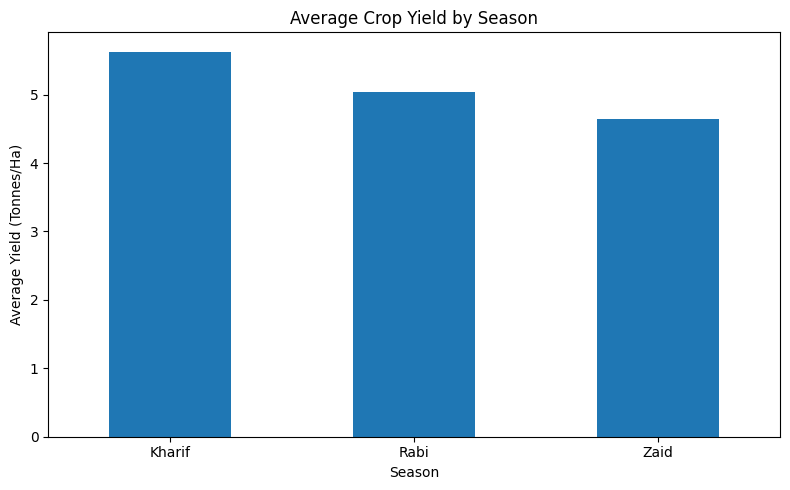

In [22]:
import matplotlib.pyplot as plt

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
season_yield.plot(kind='bar')
plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

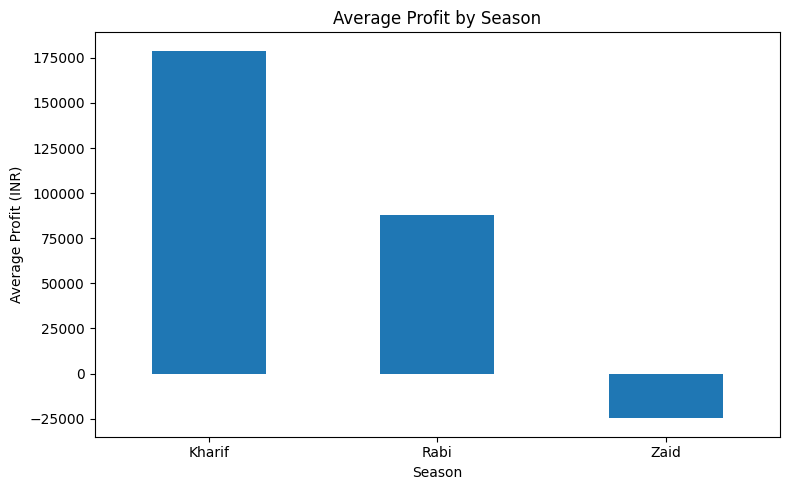

In [23]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
season_profit.plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
import seaborn as sns

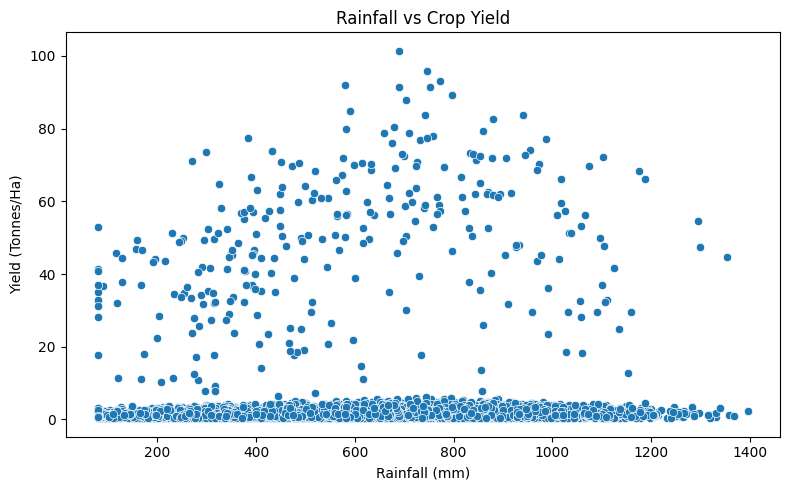

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

In [27]:
correlation = df[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Soil_Moisture_pct',
        'Yield_Tonnes_Ha',
        'Profit_INR'
    ]
].corr()

correlation

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000000,0.198492,0.508941,0.030951,0.107648
Avg_Temperature_C,0.198492,1.000000,0.084001,0.009996,0.009043
Soil_Moisture_pct,0.508941,0.084001,1.000000,0.010999,0.091281
Yield_Tonnes_Ha,0.030951,0.009996,0.010999,1.000000,0.488466
Profit_INR,0.107648,0.009043,0.091281,0.488466,1.000000


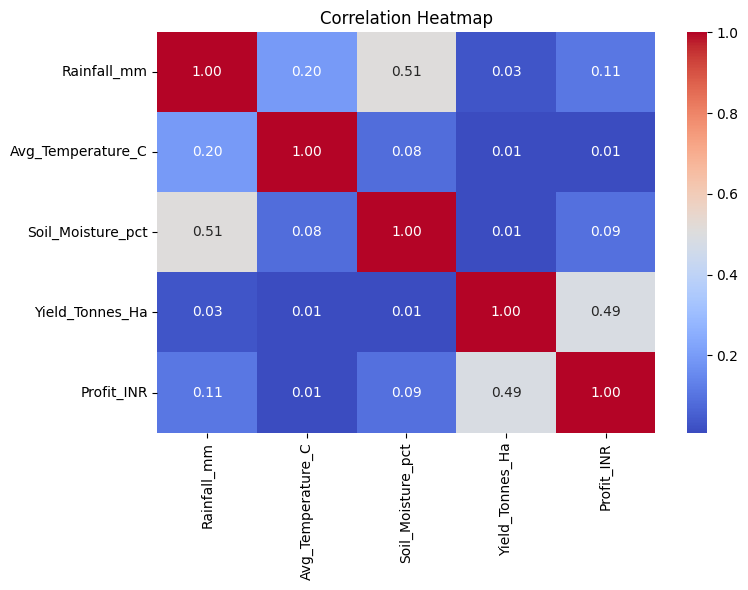

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [29]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


In [30]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

crop_profit

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


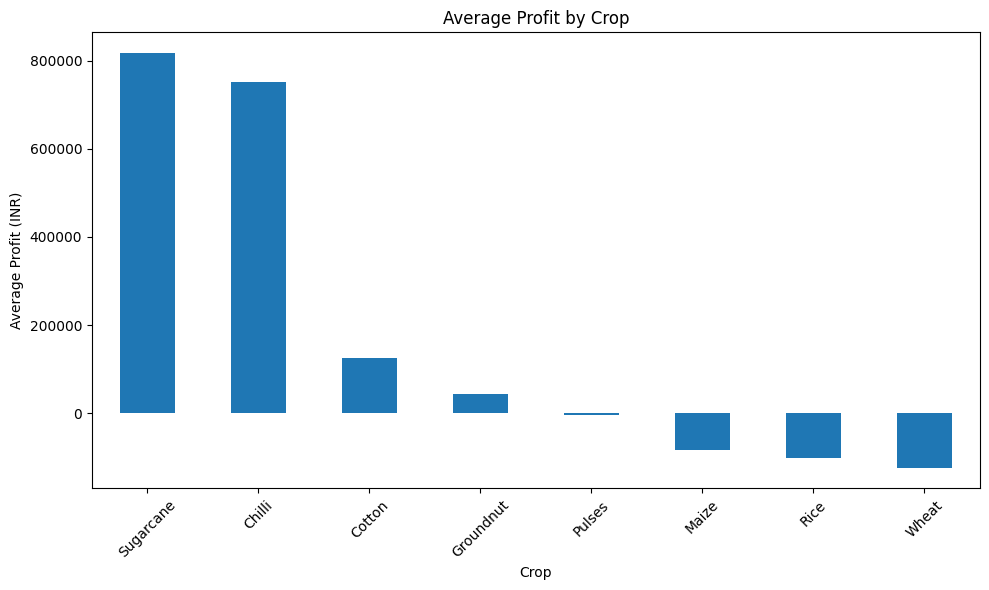

In [31]:
plt.figure(figsize=(10, 6))

crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
crop_season_yield = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


In [33]:
crop_season_profit = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


In [34]:
crop_water_efficiency = df.groupby('Crop')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

crop_water_efficiency

,Water_Efficiency_t_per_1000m3
Crop,
Sugarcane,30.477672
Maize,5.602995
Wheat,4.628393
Groundnut,3.154795
Chilli,2.947709
Pulses,2.896504
Rice,1.946112
Cotton,1.938016


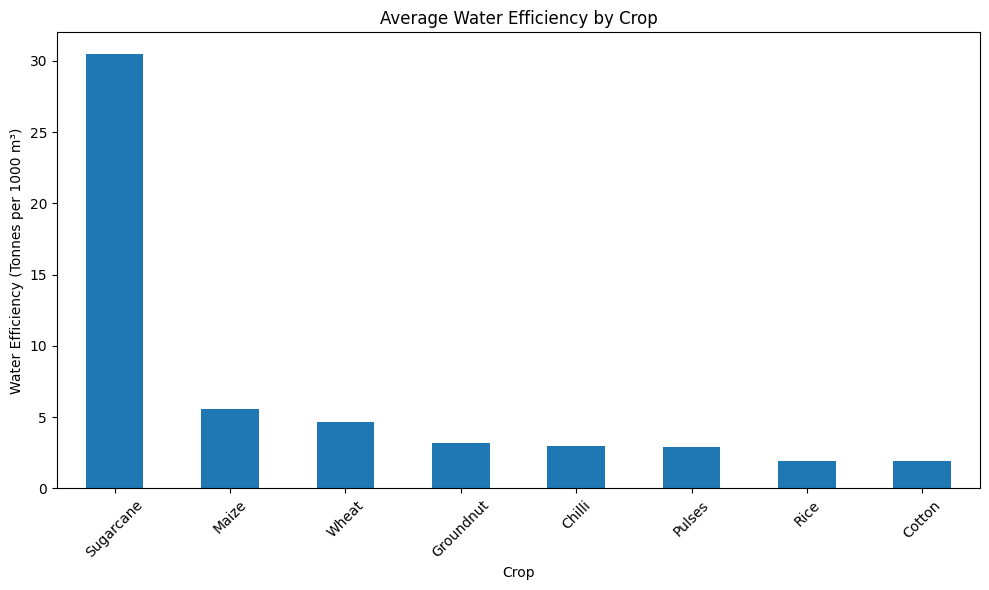

In [35]:
plt.figure(figsize=(10, 6))

crop_water_efficiency.plot(kind='bar')

plt.title('Average Water Efficiency by Crop')
plt.xlabel('Crop')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

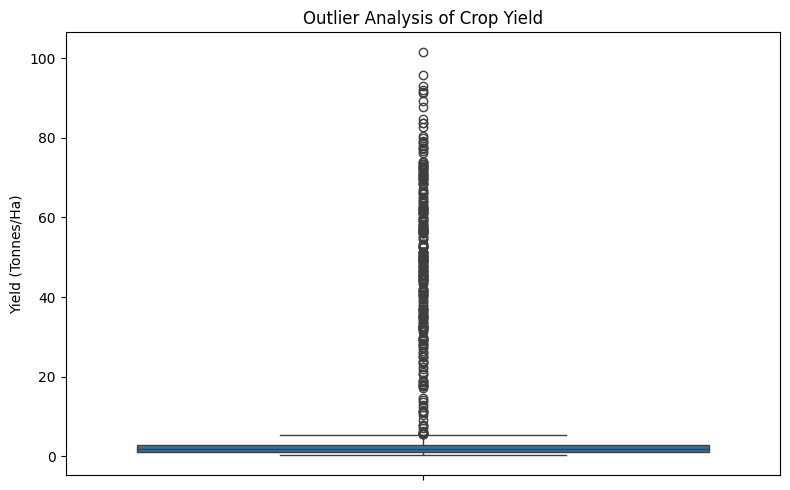

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['Yield_Tonnes_Ha'])

plt.title('Outlier Analysis of Crop Yield')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

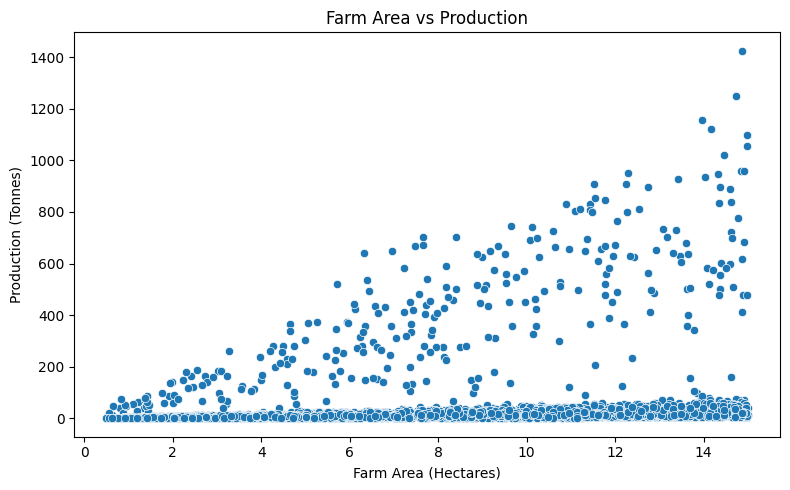

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Farm_Area_Hectares',
    y='Production_Tonnes'
)

plt.title('Farm Area vs Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()
plt.show()

In [38]:
financial_summary = df[
    ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].describe()

financial_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
count,4.000000e+03,4.000000e+03,4.000000e+03
mean,5.263036e+05,6.378600e+05,1.115565e+05
std,2.944191e+05,6.369747e+05,5.450819e+05
min,2.682600e+04,6.107000e+03,-1.019223e+06
25%,2.745775e+05,2.075172e+05,-1.487318e+05
50%,5.190825e+05,4.568305e+05,3.673000e+03
75%,7.619965e+05,8.368748e+05,2.161878e+05
max,1.349990e+06,5.080900e+06,4.345421e+06


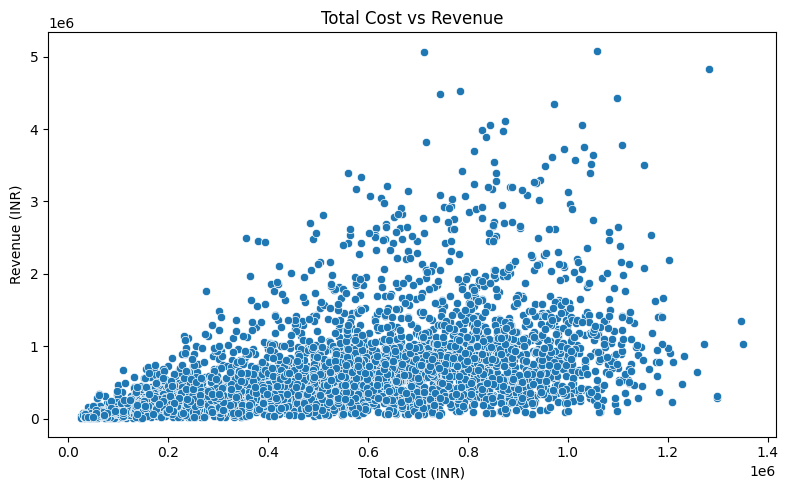

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Total_Cost_INR',
    y='Revenue_INR'
)

plt.title('Total Cost vs Revenue')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.tight_layout()
plt.show()

In [40]:
season_resource = df.groupby('Season')[
    ['Water_Used_m3', 'Yield_Tonnes_Ha']
].mean().sort_values('Yield_Tonnes_Ha', ascending=False)

season_resource

,Water_Used_m3,Yield_Tonnes_Ha
Season,,
Kharif,6102.201237,5.628612
Rabi,5846.987093,5.039435
Zaid,6419.893939,4.641313


In [41]:
top_crop = crop_yield.idxmax()
top_yield = crop_yield.max()

print("Top Performing Crop:", top_crop)
print("Average Yield:", round(top_yield, 2), "Tonnes/Ha")

Top Performing Crop: Sugarcane
Average Yield: 46.64 Tonnes/Ha


In [42]:
top_season = season_yield.idxmax()
top_season_yield = season_yield.max()

print("Top Performing Season:", top_season)
print("Average Yield:", round(top_season_yield, 2), "Tonnes/Ha")

Top Performing Season: Kharif
Average Yield: 5.63 Tonnes/Ha


In [44]:
print("===== KEY INSIGHTS =====")

print("\n1. Top Performing Crop:")
print(f"{top_crop} with average yield of {top_yield:.2f} Tonnes/Ha")

print("\n2. Top Performing Season:")
print(f"{top_season} with average yield of {top_season_yield:.2f} Tonnes/Ha")

print("\n3. Most Water-Efficient Crop:")
print(
    f"{crop_water_efficiency.idxmax()} "
    f"({crop_water_efficiency.max():.2f} Tonnes per 1000 m³)"
)

print("\n4. Most Profitable Crop:")
print(
    f"{crop_profit.idxmax()} "
    f"(Average Profit: ₹{crop_profit.max():,.2f})"
)

===== KEY INSIGHTS =====

1. Top Performing Crop:
Sugarcane with average yield of 46.64 Tonnes/Ha

2. Top Performing Season:
Kharif with average yield of 5.63 Tonnes/Ha

3. Most Water-Efficient Crop:
Sugarcane (30.48 Tonnes per 1000 m³)

4. Most Profitable Crop:
Sugarcane (Average Profit: ₹817,187.99)


In [45]:
print("===== RECOMMENDATIONS =====")

print("\n1. Sugarcane shows the strongest overall performance")
print("   in terms of yield, water efficiency and average profit.")

print("\n2. Kharif season shows the highest average yield")
print("   among the analyzed seasons.")

print("\n3. Farmers can prioritize crops and seasons")
print("   that demonstrate better yield and profitability.")

print("\n4. Water-efficient crop selection can help")
print("   improve resource utilization.")

print("\n5. Crop and seasonal performance should be monitored")
print("   regularly to support better agricultural planning.")

===== RECOMMENDATIONS =====

1. Sugarcane shows the strongest overall performance
   in terms of yield, water efficiency and average profit.

2. Kharif season shows the highest average yield
   among the analyzed seasons.

3. Farmers can prioritize crops and seasons
   that demonstrate better yield and profitability.

4. Water-efficient crop selection can help
   improve resource utilization.

5. Crop and seasonal performance should be monitored
   regularly to support better agricultural planning.


In [46]:
print("===== CONCLUSION =====")

print(
    f"The analysis shows that {top_crop} is the top-performing crop "
    f"with an average yield of {top_yield:.2f} Tonnes/Ha, "
    f"the highest water efficiency and the highest average profit."
)

print(
    f"Among the analyzed seasons, {top_season} recorded the highest "
    f"average yield of {top_season_yield:.2f} Tonnes/Ha."
)

print(
    "Overall, the analysis highlights the importance of selecting "
    "suitable crops and seasons while considering yield, profitability "
    "and efficient use of water resources."
)

===== CONCLUSION =====
The analysis shows that Sugarcane is the top-performing crop with an average yield of 46.64 Tonnes/Ha, the highest water efficiency and the highest average profit.
Among the analyzed seasons, Kharif recorded the highest average yield of 5.63 Tonnes/Ha.
Overall, the analysis highlights the importance of selecting suitable crops and seasons while considering yield, profitability and efficient use of water resources.


In [47]:
print("===== PROJECT SUMMARY =====")
print("Project: Seasonal Agriculture Performance Analysis")
print("Dataset Size: 4,000 records × 28 columns")
print(f"Top Crop: {top_crop}")
print(f"Top Season: {top_season}")
print(f"Highest Average Yield: {top_yield:.2f} Tonnes/Ha")
print(f"Most Profitable Crop: {crop_profit.idxmax()}")
print(f"Most Water-Efficient Crop: {crop_water_efficiency.idxmax()}")
print("\nAnalysis Completed Successfully!")


===== PROJECT SUMMARY =====
Project: Seasonal Agriculture Performance Analysis
Dataset Size: 4,000 records × 28 columns
Top Crop: Sugarcane
Top Season: Kharif
Highest Average Yield: 46.64 Tonnes/Ha
Most Profitable Crop: Sugarcane
Most Water-Efficient Crop: Sugarcane

Analysis Completed Successfully!


In [48]:
print("===== FINAL DATA QUALITY CHECK =====")

print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

===== FINAL DATA QUALITY CHECK =====
Missing Values: 0
Duplicate Rows: 0
Rows: 4000
Columns: 28


In [49]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

state_yield

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.685481
Gujarat,5.659016
Telangana,5.044477
Maharashtra,5.017480
Madhya Pradesh,4.989940
Tamil Nadu,4.875175
Andhra Pradesh,4.628771


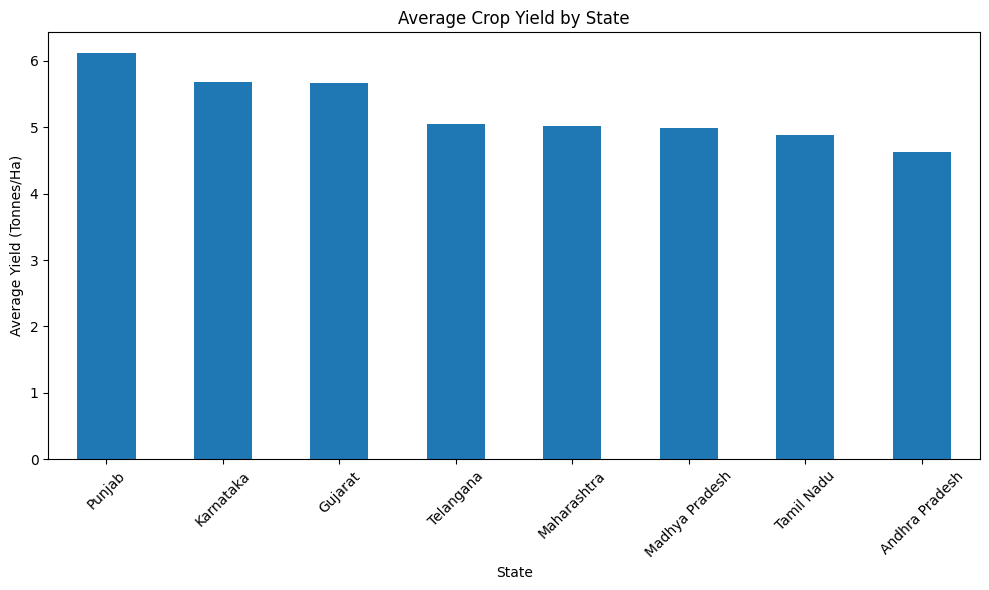

In [50]:
plt.figure(figsize=(10, 6))

state_yield.plot(kind='bar')

plt.title('Average Crop Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
print("===== UNUSUAL / IMPORTANT PATTERNS =====")

print("\n1. Highest Yield Record:")
print(
    df.loc[df['Yield_Tonnes_Ha'].idxmax(),
           ['State', 'District', 'Crop', 'Season', 'Yield_Tonnes_Ha']]
)

print("\n2. Lowest Profit Record:")
print(
    df.loc[df['Profit_INR'].idxmin(),
           ['State', 'District', 'Crop', 'Season', 'Profit_INR']]
)

print("\n3. Highest Water Usage Record:")
print(
    df.loc[df['Water_Used_m3'].idxmax(),
           ['State', 'District', 'Crop', 'Season', 'Water_Used_m3']]
)

===== UNUSUAL / IMPORTANT PATTERNS =====

1. Highest Yield Record:
State                Gujarat
District              Indore
Crop               Sugarcane
Season                Kharif
Yield_Tonnes_Ha       101.44
Name: 1715, dtype: object

2. Lowest Profit Record:
State         Andhra Pradesh
District            Ludhiana
Crop               Groundnut
Season                  Rabi
Profit_INR          -1019223
Name: 780, dtype: object

3. Highest Water Usage Record:
State            Maharashtra
District            Ludhiana
Crop               Sugarcane
Season                  Rabi
Water_Used_m3          40902
Name: 2920, dtype: object


In [52]:
print("===== FINAL PROJECT CHECK =====")

print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nTop Crop:", top_crop)
print("Top Season:", top_season)

print("\n===== PROJECT STATUS =====")
print("Seasonal Agriculture Performance Analysis")
print("Analysis Completed Successfully!")


===== FINAL PROJECT CHECK =====
Dataset Shape: (4000, 28)
Missing Values: 0
Duplicate Rows: 0

Top Crop: Sugarcane
Top Season: Kharif

===== PROJECT STATUS =====
Seasonal Agriculture Performance Analysis
Analysis Completed Successfully!
